# BC Porphyry Mapping — Landsat 8/9 STAC Pipeline

Accesses Landsat Collection 2 Level-2 imagery via Microsoft Planetary Computer STAC.  
Builds a summer median composite and computes indices relevant to porphyry alteration mapping.

**Indices computed:**
- NDVI — vegetation mask
- NDWI — water mask  
- Clay ratio (SWIR1/SWIR2) — phyllic/argillic alteration (sericite, kaolinite)
- Iron oxide ratio (Red/Blue) — hematite, goethite
- Ferrous minerals ratio (SWIR1/NIR) — chlorite, amphibole (propylitic)

**AOI:** loaded from `AOI.geojson` (place file in same directory as this notebook)

In [1]:
import numpy as np
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import planetary_computer
import pystac_client
import odc.stac
from pathlib import Path

print('imports ok')

imports ok


In [2]:
# filter by terrane
import geopandas as gpd

terranes = gpd.read_file(r'C:\Users\RexDe\Documents\Python\critical-minerals-canada\data\BC_terranes.gpkg')

print(terranes.columns.tolist())
print(terranes.crs)
print(terranes.shape)

['TERRANE', 'T_GROUP', 'AFFINITY', 'T_NAME', 'SUBTERRANE', 'TGP_SIMPLE', 'TECT_SET', 'AGE_RANGE', 'DESCRIPN', 'geometry']
EPSG:3578
(180, 10)


invalid before: 0
invalid after:  0
saved BC_terranes_clean.gpkg
bbox: [np.float64(-138.2355), np.float64(50.5181), np.float64(-121.7347), np.float64(62.9683)]


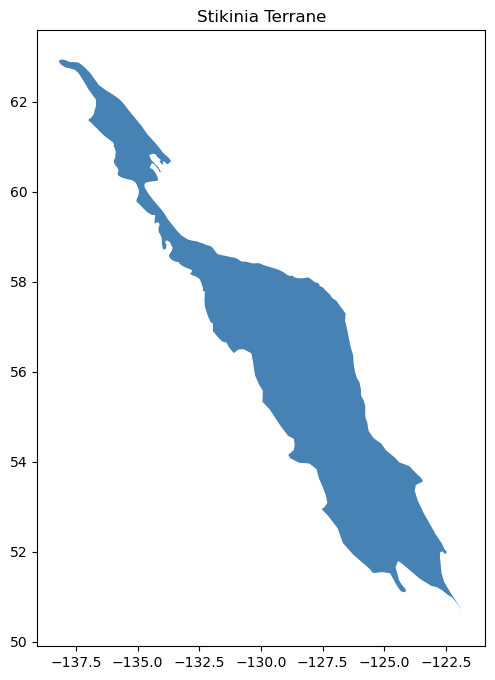

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

# load
terranes = gpd.read_file(r'C:\Users\RexDe\Documents\Python\critical-minerals-canada\data\BC_terranes.gpkg')

# fix invalid geometries across all terranes once
print(f'invalid before: {(~terranes.geometry.is_valid).sum()}')
terranes['geometry'] = terranes.geometry.buffer(0)
print(f'invalid after:  {(~terranes.geometry.is_valid).sum()}')

# save cleaned version as the canonical file
terranes.to_file(
    r'C:\Users\RexDe\Documents\Python\critical-minerals-canada\data\BC_terranes_clean.gpkg',
    driver='GPKG'
)
print('saved BC_terranes_clean.gpkg')

# filter and dissolve stikinia
stikinia = terranes[terranes['T_NAME'] == 'Stikinia'].copy()
stikinia_dissolved = stikinia.dissolve()
stikinia_wgs84 = stikinia_dissolved.to_crs('EPSG:4326')
bbox = list(stikinia_wgs84.total_bounds)
print(f'bbox: {[round(x, 4) for x in bbox]}')

fig, ax = plt.subplots(figsize=(6, 8))
stikinia_wgs84.plot(ax=ax, color='steelblue', edgecolor='white')
plt.title('Stikinia Terrane')
plt.show()

aoi = stikinia_wgs84

## 1. Load AOI

In [7]:
import json

# use actual geometry not just bbox
aoi_geom = json.loads(aoi.geometry.iloc[0].__geo_interface__['coordinates'] and 
                       aoi.to_json())
aoi_geom = aoi.geometry.iloc[0].__geo_interface__


## 2. STAC Search — Landsat Collection 2 Level-2

In [9]:
# --- config ---
date_range = '2023-07-01/2024-09-30'
cloud_cover_max = 20
collection = 'landsat-c2-l2'

catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

aoi_geom = aoi.geometry.iloc[0].__geo_interface__

search = catalog.search(
    collections=[collection],
    intersects=aoi_geom,
    datetime=date_range,
    query={'eo:cloud_cover': {'lt': cloud_cover_max}},
)

items = list(search.items())
print(f'scenes found: {len(items)}')

for item in items[:5]:
    print(f"  {item.datetime.date()}  cloud={item.properties.get('eo:cloud_cover', '?')}%  platform={item.properties.get('platform', '?')}")
if len(items) > 5:
    print(f'  ... and {len(items) - 5} more')

scenes found: 554
  2024-09-30  cloud=4.27%  platform=landsat-8
  2024-09-29  cloud=14.64%  platform=landsat-9
  2024-09-29  cloud=9.27%  platform=landsat-9
  2024-09-29  cloud=19.09%  platform=landsat-9
  2024-09-18  cloud=9.71%  platform=landsat-9
  ... and 549 more


## 3. Load Bands into xarray

In [12]:
bands = ['blue', 'green', 'red', 'nir08', 'swir16', 'swir22']

ds = odc.stac.load(
    items,
    bands=bands,
    geopolygon=aoi.geometry.iloc[0],
    resolution=300,
    groupby='solar_day',
    chunks={'time': 1, 'x': 512, 'y': 512},
)

print(ds)
print(f'\ntime steps: {len(ds.time)}')

<xarray.Dataset> Size: 35GB
Dimensions:      (y: 4645, x: 3278, time: 190)
Coordinates:
  * y            (y) float64 37kB 7.015e+06 7.014e+06 ... 5.622e+06 5.621e+06
  * x            (x) float64 26kB 3.18e+04 3.21e+04 ... 1.015e+06 1.015e+06
  * time         (time) datetime64[us] 2kB 2023-07-02T16:57:39.679957 ... 202...
    spatial_ref  int32 4B 32609
Data variables:
    blue         (time, y, x) uint16 6GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    green        (time, y, x) uint16 6GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    red          (time, y, x) uint16 6GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nir08        (time, y, x) uint16 6GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir16       (time, y, x) uint16 6GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir22       (time, y, x) uint16 6GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

time steps: 190


## 4. Scale to Surface Reflectance

Landsat C2 L2 SR values are stored as uint16. Scale factor = 0.0000275, offset = -0.2.

In [14]:
scale = 0.0000275
offset = -0.2

sr = ds.astype('float32') * scale + offset
sr = sr.clip(0, 1)

nodata_mask = ds == 0
sr = sr.where(~nodata_mask)

print('scaling applied')
print(sr)

scaling applied
<xarray.Dataset> Size: 69GB
Dimensions:      (time: 190, y: 4645, x: 3278)
Coordinates:
  * time         (time) datetime64[us] 2kB 2023-07-02T16:57:39.679957 ... 202...
  * y            (y) float64 37kB 7.015e+06 7.014e+06 ... 5.622e+06 5.621e+06
  * x            (x) float64 26kB 3.18e+04 3.21e+04 ... 1.015e+06 1.015e+06
    spatial_ref  int32 4B 32609
Data variables:
    blue         (time, y, x) float32 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    green        (time, y, x) float32 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    red          (time, y, x) float32 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nir08        (time, y, x) float32 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir16       (time, y, x) float32 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir22       (time, y, x) float32 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>


## 5. Median Composite (July–September)

In [ ]:
# search
search = catalog.search(
    collections=[collection],
    intersects=aoi_geom,
    datetime=date_range,
    query={'eo:cloud_cover': {'lt': cloud_cover_max}},
)
items = list(search.items())
items = items[:100]
print(f'scenes: {len(items)}')

# load
bands = ['blue', 'green', 'red', 'nir08', 'swir16', 'swir22']
ds = odc.stac.load(
    items,
    bands=bands,
    geopolygon=aoi.geometry.iloc[0],
    resolution=300,
    groupby='solar_day',
    chunks={'time': 1, 'x': 512, 'y': 512},
)
print(f'time steps: {len(ds.time)}')

# scale
sr = ds.astype('float32') * scale + offset
sr = sr.clip(0, 1)
sr = sr.where(ds != 0)

# compute
print('computing median composite...')
composite = sr.median(dim='time').compute()
print('done')

scenes: 100
time steps: 39
computing median composite...


## 6. Compute Indices

In [ ]:
blue  = composite['blue']
green = composite['green']
red   = composite['red']
nir   = composite['nir08']
swir1 = composite['swir16']
swir2 = composite['swir22']

def safe_ratio(a, b):
    """ratio with zero-division guard"""
    return a / b.where(b != 0)

# --- vegetation / water masks ---
ndvi = safe_ratio(nir - red, nir + red)
ndwi = safe_ratio(green - nir, green + nir)

# --- geological indices ---
# clay / phyllic alteration: sericite, kaolinite (high swir1, low swir2)
clay = safe_ratio(swir1, swir2)

# iron oxide: goethite, hematite (high red, low blue)
iron_oxide = safe_ratio(red, blue)

# ferrous minerals: chlorite, amphibole in propylitic zone
ferrous = safe_ratio(swir1, nir)

print('indices computed')
print(f'  ndvi range       : {float(ndvi.min()):.3f} – {float(ndvi.max()):.3f}')
print(f'  clay range       : {float(clay.min()):.3f} – {float(clay.max()):.3f}')
print(f'  iron oxide range : {float(iron_oxide.min()):.3f} – {float(iron_oxide.max()):.3f}')
print(f'  ferrous range    : {float(ferrous.min()):.3f} – {float(ferrous.max()):.3f}')

## 7. Apply Vegetation + Water Mask

Pixels with NDVI > 0.3 are dense vegetation (unreliable mineral signal).  
Pixels with NDWI > 0.0 are water.

In [ ]:
ndvi_threshold = 0.3    # adjust upward if AOI is sparsely vegetated
ndwi_threshold = 0.0

veg_mask   = ndvi > ndvi_threshold
water_mask = ndwi > ndwi_threshold
combined_mask = veg_mask | water_mask

clay_masked       = clay.where(~combined_mask)
iron_oxide_masked = iron_oxide.where(~combined_mask)
ferrous_masked    = ferrous.where(~combined_mask)

masked_pct = float(combined_mask.mean()) * 100
print(f'masked pixels: {masked_pct:.1f}% of AOI')
print('  (adjust ndvi_threshold above if too much is masked for a sparse-veg area)')

## 8. Visualise

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('BC Porphyry Mapping — Landsat Composite', fontsize=14, y=1.01)

def plot_band(ax, data, title, cmap='RdYlGn', vmin=None, vmax=None, mask=None):
    if mask is not None:
        plot_data = data.where(~mask)
    else:
        plot_data = data
    im = ax.imshow(
        plot_data.values,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        interpolation='none'
    )
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

# true colour rgb (gamma stretch for display)
rgb = np.stack([
    composite['red'].values,
    composite['green'].values,
    composite['blue'].values
], axis=-1)
rgb_display = np.clip(rgb / 0.3, 0, 1)  # simple linear stretch
axes[0, 0].imshow(rgb_display, interpolation='none')
axes[0, 0].set_title('True Colour (RGB)', fontsize=11)
axes[0, 0].axis('off')

# ndvi
plot_band(axes[0, 1], ndvi, 'NDVI', cmap='RdYlGn', vmin=-0.2, vmax=0.8)

# ndwi
plot_band(axes[0, 2], ndwi, 'NDWI (water)', cmap='Blues', vmin=-0.5, vmax=0.5)

# clay ratio — masked
plot_band(axes[1, 0], clay_masked, 'Clay Ratio SWIR1/SWIR2\n(phyllic/argillic alteration)',
          cmap='hot', vmin=0.8, vmax=1.4)

# iron oxide — masked
plot_band(axes[1, 1], iron_oxide_masked, 'Iron Oxide Ratio Red/Blue\n(hematite/goethite)',
          cmap='OrRd', vmin=0.5, vmax=2.5)

# ferrous — masked
plot_band(axes[1, 2], ferrous_masked, 'Ferrous Ratio SWIR1/NIR\n(chlorite/amphibole propylitic)',
          cmap='YlOrBr', vmin=0.3, vmax=1.2)

plt.tight_layout()
plt.savefig('porphyry_indices.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved porphyry_indices.png')

## 9. Export GeoTIFFs

Writes each masked index as a GeoTIFF — ready to load into QGIS for interpretation alongside geochemistry.

In [ ]:
out_dir = Path('output_indices')
out_dir.mkdir(exist_ok=True)

# copy crs and transform from composite
crs = composite.rio.crs
if crs is None:
    # odc.stac should set this, but just in case
    composite = composite.rio.write_crs('EPSG:32610')  # UTM zone 10N — adjust for your AOI
    crs = composite.rio.crs

def export_index(da, name):
    da_out = da.rio.write_crs(crs).rio.write_nodata(np.nan)
    path = out_dir / f'{name}.tif'
    da_out.rio.to_raster(path, dtype='float32')
    print(f'  exported: {path}')

print('exporting...')
export_index(ndvi,            'ndvi')
export_index(ndwi,            'ndwi')
export_index(clay_masked,     'clay_ratio')
export_index(iron_oxide_masked, 'iron_oxide_ratio')
export_index(ferrous_masked,  'ferrous_ratio')
print('all done — load tifs into qgis alongside geochemistry')

## Notes

**Interpreting the indices for porphyry:**
- High clay ratio + high iron oxide in the same pixel cluster → likely potassic or phyllic zone
- Elevated ferrous at the margins → propylitic halo
- Use geochemistry (Au, Cu, Mo anomalies) to ground-truth spatial clusters

**Adjustments to consider:**
- `ndvi_threshold`: lower to 0.2 in dense forest, raise to 0.4+ in semi-arid terrain
- `date_range`: narrow to a single year if you want less temporal averaging
- `resolution`: 30m is Landsat native; you can upsample but it won't add real detail
- Sentinel-2 follow-up: pull B8A (narrow NIR) + B11/B12 for higher-res corroboration in exposed areas